In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
from math import ceil
from scipy.stats import gaussian_kde
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import random


try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

In [2]:
geneticsData = pd.read_csv('../data/GNPC_Harmonized_Dataset_V1/GeneticsV1_anonymized.csv')
geneticsData.head()

,contributor_code,sample_id,gene,variant
0,R,6cafef94-c7c7-4b94-a2db-001b1e9bc258,APOE,34
1,C,69e4c6ae-4523-4146-aebb-001d13bb5146,APOE,32
2,F,aa2f62aa-c0d3-40f8-9d51-0077c2ff098e,APOE,33
3,Q,ab15806d-4c39-482d-a91c-301972a0c4b5,APOE,44
4,H,968c7201-f58f-41a9-a2b4-00db0c972e19,APOE,33


In [10]:
def sample_duplicates_test(df):
    grouped = df.groupby("sample_id")
    for name, group in grouped:
        if (len(group) > 1):
            print(f"Sample ID: {name}")
            print(group)
            break  # Just show the first group for brevity

In [11]:
sample_duplicates_test(geneticsData)

Sample ID: 001886bf-3b1f-49cd-a7fc-4a1ec3f765c1
     contributor_code                             sample_id  gene  variant
8328                N  001886bf-3b1f-49cd-a7fc-4a1ec3f765c1  MAPT        0
8329                N  001886bf-3b1f-49cd-a7fc-4a1ec3f765c1    C9        0
8330                N  001886bf-3b1f-49cd-a7fc-4a1ec3f765c1   GRN        0


In [3]:
# sample source data
somaMeta = pd.read_csv('../data/GNPC_Harmonized_Dataset_V1/SomalogicMetaV1_anonymized.csv')
somaMeta.head()

/tmp/ipykernel_524096/3545570142.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  somaMeta = pd.read_csv('../data/GNPC_Harmonized_Dataset_V1/SomalogicMetaV1_anonymized.csv')


,sample_id,contributor_code,visit,plate_id,units,anml_fraction_used_0_005,anml_fraction_used_0_5,anml_fraction_used_20,anml_fraction_used_20_s1,anml_fraction_used_20_s2,...,hyb_control_norm_scale,norm_scale_0_005,norm_scale_0_5,norm_scale_20,norm_scale_20_s1,norm_scale_20_s2,norm_scale_20_s3,row_check,sample_matrix,sample_type
0,8a0e5419-20f3-44d6-bb46-bab165bf8d05,R,1,147,-1,0.866,0.836,0.847,-1.0,-1.0,...,0.934112,1.435652,0.824065,0.722277,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample
1,1f2178f2-83a6-46df-aec1-3dd741621068,R,2,147,-1,0.936,0.947,0.954,-1.0,-1.0,...,0.884058,0.894184,0.804804,0.841661,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample
2,40c3925c-a770-4adc-9a87-5d9e2a23b855,R,1,147,-1,0.973,0.939,0.913,-1.0,-1.0,...,0.906697,1.100648,1.043171,0.901319,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample
3,9de3c941-b32b-4ef8-8d59-6b57b905c657,R,2,147,-1,0.888,0.843,0.859,-1.0,-1.0,...,0.994137,1.165921,0.942466,0.825704,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample
4,03830809-3976-4f58-8279-ca2ffd0398c4,R,2,147,-1,0.850,0.828,0.804,-1.0,-1.0,...,0.925489,1.061411,0.659705,0.608147,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample


In [12]:
sample_duplicates_test(somaMeta)

In [4]:
# clinical subject data
clinicalData = pd.read_csv('../data/GNPC_Harmonized_Dataset_V1/ClinicalV1_anonymized.csv')
clinicalData.head()

,contributor_code,sample_id,sequential_visit_number,age_at_visit,computed_age_range,sex,race,years_of_education,computed_years_education_range,computed_height_range,...,anxiety,cdr,cognitive_test_date,cognitive_test_score,computed_cognitive_test_score,cognitive_test_battery,computed_clinical_diagnosis,computed_cognitive_impairment,is_neuropath,is_biomarker
0,A,2d5cc071-c66c-4a10-b55b-00d6eb03b6f3,1,69,0,1,5,14,0,0,...,0,-1.0,8/25/2021,30,1,MMSE,-1,0,0,0
1,A,26ac68a0-91e9-4d7e-8b58-00e737c3bcd7,1,76,0,1,5,4,2,0,...,0,-1.0,9/23/2022,23,1,MMSE,1,1,0,0
2,A,28f4a373-ba8e-4832-8485-0158dfd8c62b,1,65,0,2,2,14,0,0,...,1,-1.0,1/13/2022,20,1,MMSE,1,1,0,0
3,A,64b27523-4353-420e-b01a-024c470ccf90,1,65,0,2,2,14,0,0,...,0,-1.0,12/10/2021,26,1,MMSE,2,1,0,0
4,A,b68baa17-b013-412d-bf71-0254b6945e8d,1,73,0,2,2,18,0,0,...,0,-1.0,9/28/2021,27,1,MMSE,-1,0,0,0


In [13]:
sample_duplicates_test(clinicalData)

In [5]:
# clinical subject to sample mapping data
mappingData = pd.read_csv('../data/GNPC_Harmonized_Dataset_V1/PersonMappingV1_anonymized.csv')
mappingData.head()

,person_id,sample_id,is_somalogic,is_mass_spec
0,8aee12c9-962e-48f4-9d15-0008e4443c9d,8aee12c9-962e-48f4-9d15-0008e4443c9d,1,0
1,cd284063-9250-4149-9e8a-0009a615b59d,cd284063-9250-4149-9e8a-0009a615b59d,1,0
2,20fb319a-13a8-4284-83f6-000d1942beb2,20fb319a-13a8-4284-83f6-000d1942beb2,1,0
3,c0493c35-5a4f-4b34-8bdd-000e0c492ae1,c0493c35-5a4f-4b34-8bdd-000e0c492ae1,1,0
4,c0493c35-5a4f-4b34-8bdd-000e0c492ae1,7cdd93db-f393-4a53-a9cb-7cd67ef4b60b,1,0


In [15]:
sample_duplicates_test(mappingData)

In [6]:
# Separate different sample matrices into different dataframes
somaGroups = {key: subdf for key, subdf in somaMeta.groupby("sample_matrix")}
plasmaSoma = somaGroups["EDTA Plasma"]
plasmaSoma.head()

,sample_id,contributor_code,visit,plate_id,units,anml_fraction_used_0_005,anml_fraction_used_0_5,anml_fraction_used_20,anml_fraction_used_20_s1,anml_fraction_used_20_s2,...,hyb_control_norm_scale,norm_scale_0_005,norm_scale_0_5,norm_scale_20,norm_scale_20_s1,norm_scale_20_s2,norm_scale_20_s3,row_check,sample_matrix,sample_type
0,8a0e5419-20f3-44d6-bb46-bab165bf8d05,R,1,147,-1,0.866,0.836,0.847,-1.0,-1.0,...,0.934112,1.435652,0.824065,0.722277,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample
1,1f2178f2-83a6-46df-aec1-3dd741621068,R,2,147,-1,0.936,0.947,0.954,-1.0,-1.0,...,0.884058,0.894184,0.804804,0.841661,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample
2,40c3925c-a770-4adc-9a87-5d9e2a23b855,R,1,147,-1,0.973,0.939,0.913,-1.0,-1.0,...,0.906697,1.100648,1.043171,0.901319,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample
3,9de3c941-b32b-4ef8-8d59-6b57b905c657,R,2,147,-1,0.888,0.843,0.859,-1.0,-1.0,...,0.994137,1.165921,0.942466,0.825704,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample
4,03830809-3976-4f58-8279-ca2ffd0398c4,R,2,147,-1,0.850,0.828,0.804,-1.0,-1.0,...,0.925489,1.061411,0.659705,0.608147,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample


In [14]:
def merge_left(df1, df2, id_col="sample_id"):
    merged = df1.merge(df2, on=id_col, how="left", suffixes=("", "_dup"))
    dup_cols = [c for c in merged.columns if c.endswith("_dup")]
    return merged.drop(columns=dup_cols)

def merge_meta(selected_meta, mapping, clinicalData):
    merged_with_mapping = merge_left(selected_meta, mapping, id_col="sample_id")
    merged_with_clinical = merge_left(merged_with_mapping, clinicalData, id_col="sample_id")
    
    # Check if the two columns exist
    if "visit" not in merged_with_clinical.columns or "sequential_visit_number" not in merged_with_clinical.columns:
        pass

    # Check if values are identical
    elif (merged_with_clinical["visit"] == merged_with_clinical["sequential_visit_number"]).all():
        # Drop sequential_visit_number if identical
        merged_with_clinical = merged_with_clinical.drop(columns=["sequential_visit_number"])
        print("Dropped 'sequential_visit_number' because it is identical to 'visit'.")
    else:
        # Raise error if they differ
        mismatched_rows = merged_with_clinical[merged_with_clinical["visit"] != merged_with_clinical["sequential_visit_number"]]
        raise ValueError(
            f"'visit' and 'sequential_visit_number' differ in {len(mismatched_rows)} rows."
        )
    return merged_with_clinical
plasmaSomaMerged = merge_meta(plasmaSoma, mappingData, clinicalData)
plasmaSomaMerged.head()

Dropped 'sequential_visit_number' because it is identical to 'visit'.


,sample_id,contributor_code,visit,plate_id,units,anml_fraction_used_0_005,anml_fraction_used_0_5,anml_fraction_used_20,anml_fraction_used_20_s1,anml_fraction_used_20_s2,...,anxiety,cdr,cognitive_test_date,cognitive_test_score,computed_cognitive_test_score,cognitive_test_battery,computed_clinical_diagnosis,computed_cognitive_impairment,is_neuropath,is_biomarker
0,8a0e5419-20f3-44d6-bb46-bab165bf8d05,R,1,147,-1,0.866,0.836,0.847,-1.0,-1.0,...,-1,-1.0,1/1/1900,28,1,MMSE,-1,0,1,0
1,1f2178f2-83a6-46df-aec1-3dd741621068,R,2,147,-1,0.936,0.947,0.954,-1.0,-1.0,...,-1,-1.0,1/1/1900,28,1,MMSE,-1,0,1,0
2,40c3925c-a770-4adc-9a87-5d9e2a23b855,R,1,147,-1,0.973,0.939,0.913,-1.0,-1.0,...,-1,-1.0,1/1/1900,30,1,MMSE,-1,0,1,0
3,9de3c941-b32b-4ef8-8d59-6b57b905c657,R,2,147,-1,0.888,0.843,0.859,-1.0,-1.0,...,-1,-1.0,1/1/1900,28,1,MMSE,-1,0,1,0
4,03830809-3976-4f58-8279-ca2ffd0398c4,R,2,147,-1,0.850,0.828,0.804,-1.0,-1.0,...,-1,-1.0,1/1/1900,28,1,MMSE,-1,0,1,0


In [16]:
def sample_summary(df, cols = None):
    if cols is None:
        cols = ["person_id", "sample_id", "sex", "contributor_code", "sample_type", "visit", "age_at_visit", "ad", "ftd", "pd", "als", "mci_sci", "recruited_control", "cdr", "cognitive_test_date", "cognitive_test_score", "computed_cognitive_test_score", "cognitive_test_battery", "computed_clinical_diagnosis", "computed_cognitive_impairment", "is_neuropath", "is_biomarker"]
    subdf = df[cols]
    return subdf

plasmaSomaSummary = sample_summary(plasmaSomaMerged)
plasmaSomaSummary.head()

,person_id,sample_id,sex,contributor_code,sample_type,visit,age_at_visit,ad,ftd,pd,...,recruited_control,cdr,cognitive_test_date,cognitive_test_score,computed_cognitive_test_score,cognitive_test_battery,computed_clinical_diagnosis,computed_cognitive_impairment,is_neuropath,is_biomarker
0,8a0e5419-20f3-44d6-bb46-bab165bf8d05,8a0e5419-20f3-44d6-bb46-bab165bf8d05,2,R,Sample,1,88,0,-1,0,...,2,-1.0,1/1/1900,28,1,MMSE,-1,0,1,0
1,a398ecfd-c26b-4e4b-8ca0-9915be6bb958,1f2178f2-83a6-46df-aec1-3dd741621068,1,R,Sample,2,72,0,-1,0,...,2,-1.0,1/1/1900,28,1,MMSE,-1,0,1,0
2,40c3925c-a770-4adc-9a87-5d9e2a23b855,40c3925c-a770-4adc-9a87-5d9e2a23b855,2,R,Sample,1,77,0,-1,0,...,2,-1.0,1/1/1900,30,1,MMSE,-1,0,1,0
3,8a0e5419-20f3-44d6-bb46-bab165bf8d05,9de3c941-b32b-4ef8-8d59-6b57b905c657,2,R,Sample,2,90,0,-1,0,...,2,-1.0,1/1/1900,28,1,MMSE,-1,0,1,0
4,92c1caea-95f8-4740-a038-04a85f106b62,03830809-3976-4f58-8279-ca2ffd0398c4,2,R,Sample,2,90,0,-1,0,...,2,-1.0,1/1/1900,28,1,MMSE,-1,0,1,0


In [ ]:
def longitudinal_align(df_merged, keyword="visit"):
    # Group by person_id and generate list of sub-dataframes
    subdfs = [subdf for _, subdf in df_merged.groupby("person_id")]
    misaligned_person_ids = [] 
    longitudinal_person_ids = []
    for subdf in subdfs:
        if subdf[keyword].max() != len(subdf):
            print("Warning: visit numbers are not sequential for person_id:", subdf["person_id"].iloc[0])
            print(subdf[[keyword, "sample_matrix"]] if keyword == "sequential_visit_number" else subdf[[keyword]])
            misaligned_person_ids.append(subdf["person_id"].iloc[0])
        if len(subdf) > 1:
            longitudinal_person_ids.append(subdf["person_id"].iloc[0])
    print(f"Total misaligned person_ids: {len(misaligned_person_ids)}")
    print(f"Total longitudinal person_ids: {len(longitudinal_person_ids)}")
    return misaligned_person_ids, longitudinal_person_ids
misaligned_person_ids, longitudinal_person_ids = longitudinal_align(plasmaSomaSummary)
# Misaligned person due to during the same visit multiple sample matrix samples were taken

      visit
6400      2
      visit
5714      2
      visit
4579      2
      visit
6768      2
      visit
6761      2
      visit
6108      2
Total misaligned person_ids: 6
Total longitudinal person_ids: 2591


In [193]:
clinical_merged = merge_left(clinicalData, mappingData, id_col="sample_id")
clinical_merged = merge_left(clinical_merged, somaMeta, id_col="sample_id")
print(clinical_merged.contributor_code.unique())
for pid in misaligned_person_ids:
    subdf = clinical_merged[clinical_merged.person_id == pid]
    print(subdf[["sequential_visit_number", "sample_matrix"]])

['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W']
       sequential_visit_number sample_matrix
21613                        2           CSF
21631                        1           CSF
26617                        2   EDTA Plasma
       sequential_visit_number sample_matrix
21700                        1           CSF
23563                        2           CSF
23565                        2   EDTA Plasma
       sequential_visit_number sample_matrix
21590                        2           CSF
23575                        1           CSF
24835                        2   EDTA Plasma
       sequential_visit_number sample_matrix
23571                        1           CSF
23599                        2           CSF
24828                        2   EDTA Plasma
       sequential_visit_number sample_matrix
23688                        1           CSF
23698                        2   EDTA Plasma
       sequential_visit_number sample_matrix
21627

In [191]:
P_clinical = clinical_merged[clinical_merged.contributor_code == "P"]
print(P_clinical.sequential_visit_number.value_counts())
print(P_clinical.ad.value_counts())
print(P_clinical.mci_sci.value_counts())
print(P_clinical.recruited_control.value_counts())
print(P_clinical.pd.value_counts())
print(P_clinical.ftd.value_counts())
print(P_clinical.als.value_counts())
P_clinical.head()

sequential_visit_number
1    519
2    501
3    351
4    105
5     15
Name: count, dtype: int64
ad
-1    1491
Name: count, dtype: int64
mci_sci
0    1326
1     165
Name: count, dtype: int64
recruited_control
2    1491
Name: count, dtype: int64
pd
-1    1491
Name: count, dtype: int64
ftd
-1    1491
Name: count, dtype: int64
als
-1    1491
Name: count, dtype: int64


,contributor_code,sample_id,sequential_visit_number,age_at_visit,computed_age_range,sex,race,years_of_education,computed_years_education_range,computed_height_range,...,hyb_control_norm_scale,norm_scale_0_005,norm_scale_0_5,norm_scale_20,norm_scale_20_s1,norm_scale_20_s2,norm_scale_20_s3,row_check,sample_matrix,sample_type
15968,P,54496116-b617-414d-8845-0016c657210d,1,72,0,2,-1,18,0,-1,...,1.008977,1.013557,0.860394,0.709699,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample
15969,P,54c5448c-b58a-4222-ae5a-001ab87100b4,1,74,0,1,-1,12,0,-1,...,0.982944,0.834050,0.665260,0.614514,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample
15970,P,bab52722-99de-4588-8c16-009da7e74735,4,81,1,2,-1,16,0,-1,...,0.967335,0.817106,0.686729,0.622656,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample
15971,P,bdec851d-7a27-4eee-a038-00d9f6b0e29d,3,77,0,2,-1,12,0,-1,...,1.163856,0.859663,0.732986,0.622481,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample
15972,P,df8cc7c4-ca8c-4ca3-b775-02ab437f1992,4,62,0,2,-1,13,0,-1,...,1.019786,0.854346,0.689518,0.581871,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample


In [ ]:
for cohort in ["B", "D", "F", "I", "J", "M", "P", "R", "T"]:
    print(f"Cohort {cohort}")
    clinical = clinical_merged[(clinical_merged.contributor_code == cohort) & (clinical_merged.sample_matrix == "EDTA Plasma")]
    misaligned, longitudinal = longitudinal_align(clinical, keyword="sequential_visit_number")
# misaligned person in cohort T due to within multiple visitsnot all visits having plasma samples

Cohort B
Total misaligned person_ids: 0
Total longitudinal person_ids: 443
Cohort D
Total misaligned person_ids: 0
Total longitudinal person_ids: 254
Cohort F
Total misaligned person_ids: 0
Total longitudinal person_ids: 207
Cohort I
Total misaligned person_ids: 0
Total longitudinal person_ids: 386
Cohort J
Total misaligned person_ids: 0
Total longitudinal person_ids: 266
Cohort M
Total misaligned person_ids: 0
Total longitudinal person_ids: 230
Cohort P
Total misaligned person_ids: 0
Total longitudinal person_ids: 501
Cohort R
Total misaligned person_ids: 0
Total longitudinal person_ids: 235
Cohort T
       sequential_visit_number sample_matrix
26617                        2   EDTA Plasma
       sequential_visit_number sample_matrix
23565                        2   EDTA Plasma
       sequential_visit_number sample_matrix
24835                        2   EDTA Plasma
       sequential_visit_number sample_matrix
24828                        2   EDTA Plasma
       sequential_visit_number 

In [194]:
K_clinical = clinical_merged[clinical_merged.contributor_code == "K"]
print(K_clinical.sequential_visit_number.value_counts())
print(K_clinical.sequential_visit_number.value_counts())
print(K_clinical.ad.value_counts())
print(K_clinical.mci_sci.value_counts())
print(K_clinical.recruited_control.value_counts())
print(K_clinical.pd.value_counts())
print(K_clinical.ftd.value_counts())
print(K_clinical.als.value_counts())
K_clinical.head()

sequential_visit_number
1    406
Name: count, dtype: int64
sequential_visit_number
1    406
Name: count, dtype: int64
ad
0    406
Name: count, dtype: int64
mci_sci
-1    406
Name: count, dtype: int64
recruited_control
0    406
Name: count, dtype: int64
pd
0    406
Name: count, dtype: int64
ftd
0    406
Name: count, dtype: int64
als
0    406
Name: count, dtype: int64


,contributor_code,sample_id,sequential_visit_number,age_at_visit,computed_age_range,sex,race,years_of_education,computed_years_education_range,computed_height_range,...,hyb_control_norm_scale,norm_scale_0_005,norm_scale_0_5,norm_scale_20,norm_scale_20_s1,norm_scale_20_s2,norm_scale_20_s3,row_check,sample_matrix,sample_type
12056,K,b0a7f762-1d01-4506-9cc9-001e267b0e4b,1,72,0,1,-1,-1,-1,1,...,1.013946,0.927833,0.828811,0.837855,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample
12057,K,404fd5af-14e0-4efb-9012-0048cd564998,1,68,0,2,-1,-1,-1,0,...,1.113062,0.936799,0.861140,0.776035,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample
12058,K,057b8d41-16a5-4175-bd15-0084dcaeb766,1,72,0,1,-1,-1,-1,1,...,1.047896,0.809780,0.723442,0.762323,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample
12059,K,04af0007-db82-41b3-b7a5-017784fc13d5,1,66,0,2,-1,-1,-1,0,...,1.006010,0.987844,1.266682,0.966576,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample
12060,K,6eeb7082-a70c-4f0d-b707-04146d8e8bff,1,65,0,1,-1,-1,-1,1,...,0.925343,0.950401,0.884416,0.856898,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample


In [144]:
plasmaSomaSummary.cognitive_test_score.describe()

count    23000.000000
mean        27.701130
std         19.793371
min         -1.000000
25%         23.000000
50%         28.000000
75%         30.000000
max        129.000000
Name: cognitive_test_score, dtype: float64

In [121]:
test = plasmaSomaSummary[(plasmaSomaSummary.ad == 1) & (plasmaSomaSummary.mci_sci == 1)]
test[["ad", "ftd", "pd", "als", "mci_sci", "recruited_control"]]

,ad,ftd,pd,als,mci_sci,recruited_control
7,1,-1,0,-1,1,2
24,1,-1,0,-1,1,2
32,1,-1,1,-1,1,2
387,1,-1,0,-1,1,2
390,1,-1,0,-1,1,2
...,...,...,...,...,...,...
20000,1,-1,0,-1,1,0
20003,1,-1,0,-1,1,0
21920,1,-1,-1,-1,1,2
22004,1,-1,-1,-1,1,2


In [200]:
def AD_plasma_longitudinal_filter(df, misaligned_person_ids):
    # cohorts = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W']
    plasma_long_cohorts = ["B", "D", "F", "I", "J", "M", "P", "R", "T"]
    AD_cohorts = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "L", "N", "P", "Q", "R", "V", "W"]
    # AD_mixed_cohorts = ["C", "D", "F", "I", "J", "L", "N", "Q", "R", "W"]
    cohorts_filter = set(AD_cohorts).intersection(set(plasma_long_cohorts))
    print(f"Selected cohorts for AD plasma longitudinal analysis: {cohorts_filter}")
    selected_df = df[df["contributor_code"].isin(cohorts_filter)]
    # selected_df = selected_df[(selected_df["ad"].isin([0, 1])) | (selected_df["mci_sci"] == 1)]
    # selected_df = selected_df[(selected_df["ad"].isin([0, 1]))]
    # selected_df = selected_df[selected_df["sex"].isin([1, 2])]
    # selected_df = selected_df[selected_df["age_at_visit"] != -1]
    # selected_df = selected_df[~selected_df["person_id"].isin(misaligned_person_ids)]
    return selected_df
AD_plasma_longitudinal = AD_plasma_longitudinal_filter(plasmaSomaSummary, misaligned_person_ids)
AD_plasma_longitudinal.head()

Selected cohorts for AD plasma longitudinal analysis: {'I', 'R', 'P', 'D', 'B', 'J', 'F'}


,person_id,sample_id,sex,contributor_code,sample_type,visit,age_at_visit,ad,ftd,pd,...,recruited_control,cdr,cognitive_test_date,cognitive_test_score,computed_cognitive_test_score,cognitive_test_battery,computed_clinical_diagnosis,computed_cognitive_impairment,is_neuropath,is_biomarker
0,8a0e5419-20f3-44d6-bb46-bab165bf8d05,8a0e5419-20f3-44d6-bb46-bab165bf8d05,2,R,Sample,1,88,0,-1,0,...,2,-1.0,1/1/1900,28,1,MMSE,-1,0,1,0
1,a398ecfd-c26b-4e4b-8ca0-9915be6bb958,1f2178f2-83a6-46df-aec1-3dd741621068,1,R,Sample,2,72,0,-1,0,...,2,-1.0,1/1/1900,28,1,MMSE,-1,0,1,0
2,40c3925c-a770-4adc-9a87-5d9e2a23b855,40c3925c-a770-4adc-9a87-5d9e2a23b855,2,R,Sample,1,77,0,-1,0,...,2,-1.0,1/1/1900,30,1,MMSE,-1,0,1,0
3,8a0e5419-20f3-44d6-bb46-bab165bf8d05,9de3c941-b32b-4ef8-8d59-6b57b905c657,2,R,Sample,2,90,0,-1,0,...,2,-1.0,1/1/1900,28,1,MMSE,-1,0,1,0
4,92c1caea-95f8-4740-a038-04a85f106b62,03830809-3976-4f58-8279-ca2ffd0398c4,2,R,Sample,2,90,0,-1,0,...,2,-1.0,1/1/1900,28,1,MMSE,-1,0,1,0


In [ ]:
misaligned_person_ids, longitudinal_person_ids = longitudinal_align(AD_plasma_longitudinal)
AD_plasma_longitudinal.contributor_code.unique()
# the total longitudinal count matches the dataset supplemental table

Total misaligned person_ids: 0
Total longitudinal person_ids: 2292


array(['R', 'F', 'D', 'B', 'I', 'P', 'J'], dtype=object)

In [207]:
AD_plasma_longitudinal.groupby(["mci_sci", "ad", "ftd", "pd", "als", "recruited_control"]).size().reset_index(name="count")


,mci_sci,ad,ftd,pd,als,recruited_control,count
0,-1,-1,-1,-1,-1,2,62
1,-1,0,0,0,0,0,1
2,-1,0,0,0,0,2,2619
3,-1,0,0,1,0,2,50
4,-1,0,1,0,0,2,3
5,-1,1,0,0,0,2,1157
6,-1,1,0,1,0,2,108
7,-1,1,1,0,0,2,29
8,0,-1,-1,-1,-1,0,447
9,0,-1,-1,-1,-1,2,1447


In [223]:
def filter_longitudinal_df(df, longitudinal_person_ids):
    ref = {"mci_sci": {}, "ad": {}, "ftd": {}, "pd": {}, "als": {}, "recruited_control": {}}
    for pid in longitudinal_person_ids:
        person_df = df[df["person_id"] == pid]
        for condition in ref.keys():
            vals = person_df[condition].replace(-1, pd.NA).dropna().unique()
            for val in vals:
                if val not in ref[condition]:
                    ref[condition][val] = [pid]
                else:
                    ref[condition][val].append(pid)
    return ref
patient_conditions = filter_longitudinal_df(AD_plasma_longitudinal, longitudinal_person_ids)
        

In [224]:
from collections import defaultdict

def summarize_multi_value_patients(ref):
    """
    For each condition, report patients that belong to more than one value.

    Returns:
        dict:
        {
            condition: {
                patient_id: [value1, value2, ...]
            }
        }
    """
    summary = {}

    for condition, value_dict in ref.items():
        patient_to_values = defaultdict(set)

        # Build reverse mapping: patient -> values
        for value, patient_ids in value_dict.items():
            for pid in patient_ids:
                patient_to_values[pid].add(value)

        # Keep only patients belonging to >1 value
        multi_value_patients = {
            pid: sorted(values)
            for pid, values in patient_to_values.items()
            if len(values) > 1
        }

        summary[condition] = multi_value_patients

    return summary
summary = summarize_multi_value_patients(patient_conditions)
for condition, patients in summary.items():
    print(f"Condition: {condition}, the number of patients with multiple values: {len(patients)}")
    for pid, values in patients.items():
        print(f"  Patient ID: {pid}, Values: {values}")

Condition: mci_sci, the number of patients with multiple values: 418
  Patient ID: 001fd4c4-1e1b-492f-9a08-319bdb3c8dab, Values: [np.int64(0), np.int64(1)]
  Patient ID: 0026f18a-c3f6-4255-a173-14ab2981006e, Values: [np.int64(0), np.int64(1)]
  Patient ID: 003e3031-8478-4f29-af97-dec0815ca37e, Values: [np.int64(0), np.int64(1)]
  Patient ID: 0077a534-64e8-4bff-8d92-1f129ee3c1d4, Values: [np.int64(0), np.int64(1)]
  Patient ID: 00f0cc42-1cbd-4fd1-9558-2fc2480c1287, Values: [np.int64(0), np.int64(1)]
  Patient ID: 01fc0ac3-2b28-48f3-9e45-b3a874da1217, Values: [np.int64(0), np.int64(1)]
  Patient ID: 029ca8e4-3e27-463f-9841-201b33cc67e0, Values: [np.int64(0), np.int64(1)]
  Patient ID: 03389ff6-bf0d-4c2e-b789-a940477a18da, Values: [np.int64(0), np.int64(1)]
  Patient ID: 052dfd95-162d-4347-9564-23ce31796fde, Values: [np.int64(0), np.int64(1)]
  Patient ID: 05efe196-294b-44b3-bb34-77aeabc4297c, Values: [np.int64(0), np.int64(1)]
  Patient ID: 05fe6d82-902e-4536-84c7-7b35234b07cb, Values: [

In [225]:
from collections import defaultdict

def summarize_condition_consistency(ref):
    """
    For each condition, report:
      1) patients belonging to multiple values (inconsistent)
      2) patients belonging to exactly one value (consistent)

    Returns:
        dict:
        {
            condition: {
                "inconsistent": {
                    patient_id: [value1, value2, ...]
                },
                "consistent": {
                    value: [patient_id, ...]
                }
            }
        }
    """
    summary = {}

    for condition, value_dict in ref.items():
        patient_to_values = defaultdict(set)

        # Build reverse mapping: patient -> values
        for value, patient_ids in value_dict.items():
            for pid in patient_ids:
                patient_to_values[pid].add(value)

        inconsistent = {}
        consistent = defaultdict(list)

        for pid, values in patient_to_values.items():
            if len(values) > 1:
                inconsistent[pid] = sorted(values)
            else:
                value = next(iter(values))
                consistent[value].append(pid)

        # Optional: sort patient lists for readability
        for value in consistent:
            consistent[value].sort()

        summary[condition] = {
            "inconsistent": inconsistent,
            "consistent": dict(consistent)
        }

    return summary
condition_summary = summarize_condition_consistency(patient_conditions)
for condition, data in condition_summary.items():
    inconsistent = data["inconsistent"]
    consistent = data["consistent"]
    print(f"Condition: {condition}")
    print(f"  Inconsistent patients ({len(inconsistent)}):")
    for pid, values in inconsistent.items():
        print(f"    Patient ID: {pid}, Values: {values}")
    print(f"  Consistent patients by value:")
    for value, patient_ids in consistent.items():
        print(f"    Value: {value}, Number of Patients: {len(patient_ids)}")

Condition: mci_sci
  Inconsistent patients (418):
    Patient ID: 001fd4c4-1e1b-492f-9a08-319bdb3c8dab, Values: [np.int64(0), np.int64(1)]
    Patient ID: 0026f18a-c3f6-4255-a173-14ab2981006e, Values: [np.int64(0), np.int64(1)]
    Patient ID: 003e3031-8478-4f29-af97-dec0815ca37e, Values: [np.int64(0), np.int64(1)]
    Patient ID: 0077a534-64e8-4bff-8d92-1f129ee3c1d4, Values: [np.int64(0), np.int64(1)]
    Patient ID: 00f0cc42-1cbd-4fd1-9558-2fc2480c1287, Values: [np.int64(0), np.int64(1)]
    Patient ID: 01fc0ac3-2b28-48f3-9e45-b3a874da1217, Values: [np.int64(0), np.int64(1)]
    Patient ID: 029ca8e4-3e27-463f-9841-201b33cc67e0, Values: [np.int64(0), np.int64(1)]
    Patient ID: 03389ff6-bf0d-4c2e-b789-a940477a18da, Values: [np.int64(0), np.int64(1)]
    Patient ID: 052dfd95-162d-4347-9564-23ce31796fde, Values: [np.int64(0), np.int64(1)]
    Patient ID: 05efe196-294b-44b3-bb34-77aeabc4297c, Values: [np.int64(0), np.int64(1)]
    Patient ID: 05fe6d82-902e-4536-84c7-7b35234b07cb, Values

In [128]:
def sex_stats(df):
    sexGroups = {key: subdf for key, subdf in df.groupby("sex")}
    print("Male group sample count:", sexGroups[1].person_id.nunique() if 1 in sexGroups else 0)
    print("Female group sample count:", sexGroups[2].person_id.nunique() if 2 in sexGroups else 0)
    cohorts = df["contributor_code"].unique()
    for cohort in cohorts:
        cohort_df = df[df["contributor_code"] == cohort]
        sex_subgroups = {key: subdf for key, subdf in cohort_df.groupby("sex")}
        print(f"Cohort {cohort}:")
        print("  Male group sample count:", sex_subgroups.get(1, pd.DataFrame()).person_id.nunique() if 1 in sex_subgroups else 0)
        print("  Female group sample count:", sex_subgroups.get(2, pd.DataFrame()).person_id.nunique() if 2 in sex_subgroups else 0)
sex_stats(AD_plasma_longitudinal)

Male group sample count: 2373
Female group sample count: 3309
Cohort R:
  Male group sample count: 126
  Female group sample count: 309
Cohort F:
  Male group sample count: 1453
  Female group sample count: 1902
Cohort D:
  Male group sample count: 195
  Female group sample count: 294
Cohort B:
  Male group sample count: 176
  Female group sample count: 267
Cohort I:
  Male group sample count: 225
  Female group sample count: 320
Cohort J:
  Male group sample count: 198
  Female group sample count: 217


In [129]:
def visit_stats(df):
    visitGroups = {key: subdf for key, subdf in df.groupby("visit")}
    for visit, subdf in visitGroups.items():
        print(f"Visit {visit}: sample count = {subdf.person_id.nunique()}")
        sex_stats(subdf)
visit_stats(AD_plasma_longitudinal)

Visit 1: sample count = 5688
Male group sample count: 2373
Female group sample count: 3309
Cohort R:
  Male group sample count: 126
  Female group sample count: 309
Cohort F:
  Male group sample count: 1453
  Female group sample count: 1902
Cohort D:
  Male group sample count: 195
  Female group sample count: 294
Cohort B:
  Male group sample count: 176
  Female group sample count: 267
Cohort I:
  Male group sample count: 225
  Female group sample count: 320
Cohort J:
  Male group sample count: 198
  Female group sample count: 217
Visit 2: sample count = 1791
Male group sample count: 727
Female group sample count: 1064
Cohort R:
  Male group sample count: 64
  Female group sample count: 171
Cohort F:
  Male group sample count: 95
  Female group sample count: 112
Cohort D:
  Male group sample count: 107
  Female group sample count: 147
Cohort B:
  Male group sample count: 176
  Female group sample count: 267
Cohort I:
  Male group sample count: 156
  Female group sample count: 230
Cohor

In [133]:
def filter_multi_visit_patients(df, min_visits=3):
    patient_greq_3 = AD_plasma_longitudinal[AD_plasma_longitudinal.visit == min_visits].person_id.unique()
    print("Patients with at least", min_visits, "visits:", len(patient_greq_3))
    filtered_df = df[df["person_id"].isin(patient_greq_3)]
    return filtered_df
AD_plasma_longitudinal_multi_visit = filter_multi_visit_patients(AD_plasma_longitudinal, min_visits=3)
AD_plasma_longitudinal_multi_visit.head()

Patients with at least 3 visits: 907


,person_id,sample_id,sex,contributor_code,sample_type,visit,age_at_visit,ad,ftd,pd,...,recruited_control,cdr,cognitive_test_date,cognitive_test_score,computed_cognitive_test_score,cognitive_test_battery,computed_clinical_diagnosis,computed_cognitive_impairment,is_neuropath,is_biomarker
1393,d22aeb11-9f76-4ca5-b08e-0a757d275c71,0ff53158-a7ab-4a8d-880d-b5767e9287f7,1,F,Sample,2,73,0,0,0,...,2,0.0,1/1/1900,28,1,MMSE,0,0,0,-1
1394,9ddbfd62-6c65-4058-bf0b-09acf789663a,fd1681a2-a867-4fe2-b8b7-caecc1962e75,2,F,Sample,2,51,0,0,0,...,2,0.0,1/1/1900,30,1,MMSE,0,0,0,-1
1395,d31cb4fb-e694-49ea-abac-550c51f169cb,e75a5f74-f3b4-4ed4-a33b-0e9b6efa3ba8,1,F,Sample,2,83,1,0,0,...,2,0.5,1/1/1900,27,1,MMSE,1,1,0,-1
1396,6d6ebbca-52fb-4686-9044-1614b2f1294b,6d6ebbca-52fb-4686-9044-1614b2f1294b,2,F,Sample,1,58,0,0,0,...,2,0.0,1/1/1900,29,1,MMSE,0,0,0,-1
1397,ae712047-ac2c-4440-b95f-4c29c423a4f6,937c34bf-efd5-476f-8afe-1168279a6a05,1,F,Sample,3,86,0,0,0,...,2,0.0,1/1/1900,23,1,MMSE,0,0,0,-1


In [149]:
AD_plasma_longitudinal[AD_plasma_longitudinal.cognitive_test_score > 30].computed_cognitive_test_score.value_counts()

computed_cognitive_test_score
-2    23
-4    17
-3     2
-5     2
Name: count, dtype: int64

In [150]:
AD_plasma_longitudinal.computed_cognitive_test_score.value_counts()

computed_cognitive_test_score
 1    7604
-1    1101
-2      26
-4      17
-3       2
-5       2
Name: count, dtype: int64

In [151]:
def visit_stats(visit_df, visit_idx, sex=None):
    print(f"For visit {visit_idx} of gender {sex}: age at visit stats =\n{visit_df["age_at_visit"].replace(-1, np.nan).describe()[["mean", "std", "min", "max"]]}" if sex else f"For visit {visit_idx}: age at visit stats =\n{visit_df["age_at_visit"].replace(-1, np.nan).describe()[["mean", "std", "min", "max"]]}")
    print(f"For visit {visit_idx} of gender {sex}: AD value counts =\n{visit_df["ad"].value_counts()}" if sex else f"For visit {visit_idx}: AD value counts =\n{visit_df["ad"].value_counts()}")
    print(f"For visit {visit_idx} of gender {sex}: MCI_SCI value counts =\n{visit_df["mci_sci"].value_counts()}" if sex else f"For visit {visit_idx}: MCI_SCI value counts =\n{visit_df["mci_sci"].value_counts()}")
    print(f"For visit {visit_idx} of gender {sex}: cognitive test score stats =\n{visit_df["cognitive_test_score"].replace(-1, np.nan).describe()[["mean", "std", "min", "max"]]}" if sex else f"For visit {visit_idx}: cognitive test score stats =\n{visit_df["cognitive_test_score"].replace(-1, np.nan).describe()[["mean", "std", "min", "max"]]}")
    filtered = visit_df["cognitive_test_score"].where(visit_df["cognitive_test_score"].between(0, 30))
    print(f"For visit {visit_idx} of gender {sex}: cognitive test score (0-30) stats =\n{filtered.replace(-1, np.nan).describe()[["mean", "std", "min", "max"]]}" if sex else f"For visit {visit_idx}: cognitive test score (0-30) stats =\n{filtered.replace(-1, np.nan).describe()[["mean", "std", "min", "max"]]}")
    visit_df["age_at_visit"].plot(kind='hist', title=f'Age at Visit {visit_idx} of Gender {sex} Distribution' if sex else f'Age at Visit {visit_idx} Distribution')
    plt.xlabel('Age at Visit')
    plt.ylabel('Frequency')
    plt.show()
    visit_df["cognitive_test_score"].plot(kind='hist', title=f'Cognitive Test Score at Visit {visit_idx} of Gender {sex} Distribution' if sex else f'Cognitive Test Score at Visit {visit_idx} Distribution')
    plt.xlabel('Cognitive Test Score')
    plt.ylabel('Frequency')
    plt.show()

Patients with at least 3 visits: 907
For visit 1: age at visit stats =
mean    63.583808
std      8.830022
min     28.000000
max     90.000000
Name: age_at_visit, dtype: float64
For visit 1: AD value counts =
ad
 0    647
 1    169
-1     91
Name: count, dtype: int64
For visit 1: MCI_SCI value counts =
mci_sci
 0    590
-1    205
 1    112
Name: count, dtype: int64
For visit 1: cognitive test score stats =
mean    27.220204
std      5.422730
min      0.000000
max     88.000000
Name: cognitive_test_score, dtype: float64
For visit 1: cognitive test score (0-30) stats =
mean    27.081911
std      4.586812
min      0.000000
max     30.000000
Name: cognitive_test_score, dtype: float64


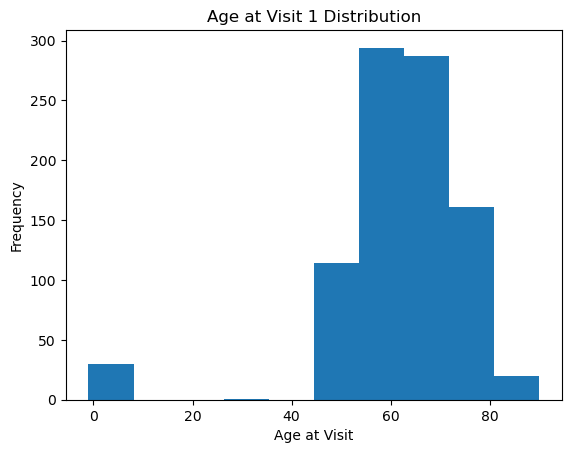

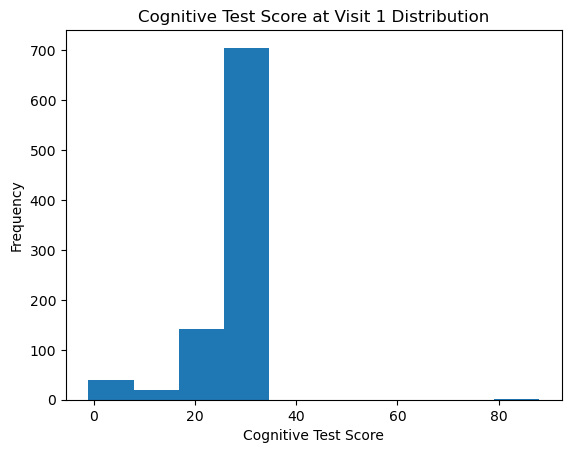

For visit 1 of gender Male: age at visit stats =
mean    64.677966
std      8.825550
min     45.000000
max     90.000000
Name: age_at_visit, dtype: float64
For visit 1 of gender Male: AD value counts =
ad
 0    254
 1     77
-1     36
Name: count, dtype: int64
For visit 1 of gender Male: MCI_SCI value counts =
mci_sci
 0    224
-1     93
 1     50
Name: count, dtype: int64
For visit 1 of gender Male: cognitive test score stats =
mean    27.214689
std      4.264513
min      0.000000
max     30.000000
Name: cognitive_test_score, dtype: float64
For visit 1 of gender Male: cognitive test score (0-30) stats =
mean    27.214689
std      4.264513
min      0.000000
max     30.000000
Name: cognitive_test_score, dtype: float64


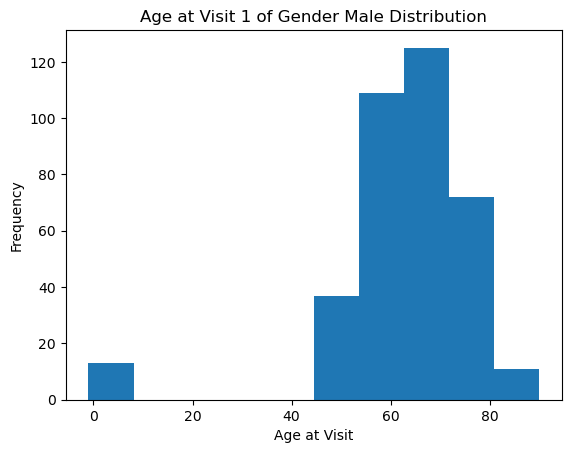

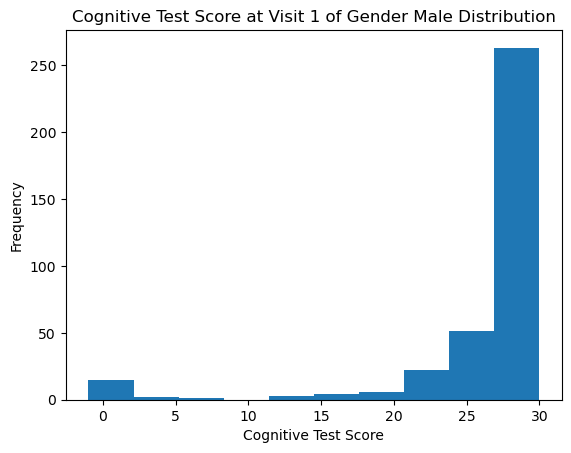

For visit 1 of gender Female: age at visit stats =
mean    62.843212
std      8.764167
min     28.000000
max     90.000000
Name: age_at_visit, dtype: float64
For visit 1 of gender Female: AD value counts =
ad
 0    393
 1     92
-1     55
Name: count, dtype: int64
For visit 1 of gender Female: MCI_SCI value counts =
mci_sci
 0    366
-1    112
 1     62
Name: count, dtype: int64
For visit 1 of gender Female: cognitive test score stats =
mean    27.223909
std      6.082072
min      0.000000
max     88.000000
Name: cognitive_test_score, dtype: float64
For visit 1 of gender Female: cognitive test score (0-30) stats =
mean    26.992381
std      4.793835
min      0.000000
max     30.000000
Name: cognitive_test_score, dtype: float64


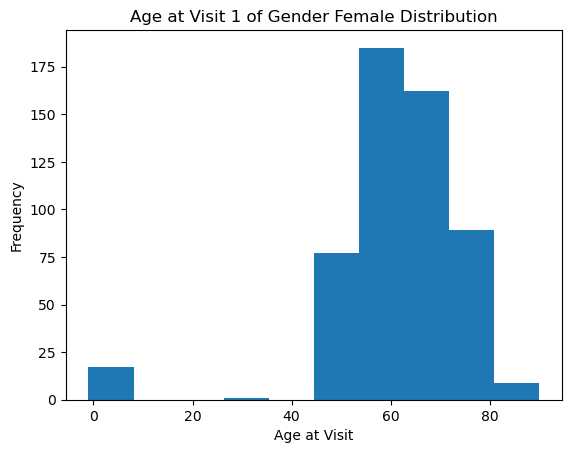

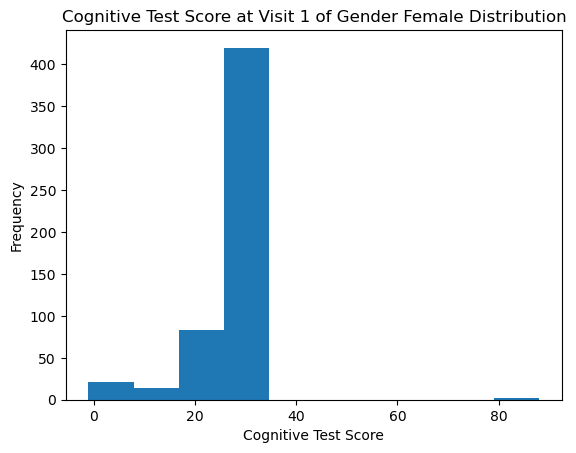

For visit 2: age at visit stats =
mean    66.651083
std      8.394880
min     33.000000
max     90.000000
Name: age_at_visit, dtype: float64
For visit 2: AD value counts =
ad
 0    634
 1    190
-1     83
Name: count, dtype: int64
For visit 2: MCI_SCI value counts =
mci_sci
 0    553
-1    205
 1    149
Name: count, dtype: int64
For visit 2: cognitive test score stats =
mean    27.218162
std      6.013660
min      0.000000
max     88.000000
Name: cognitive_test_score, dtype: float64
For visit 2: cognitive test score (0-30) stats =
mean    27.015556
std      4.890319
min      0.000000
max     30.000000
Name: cognitive_test_score, dtype: float64


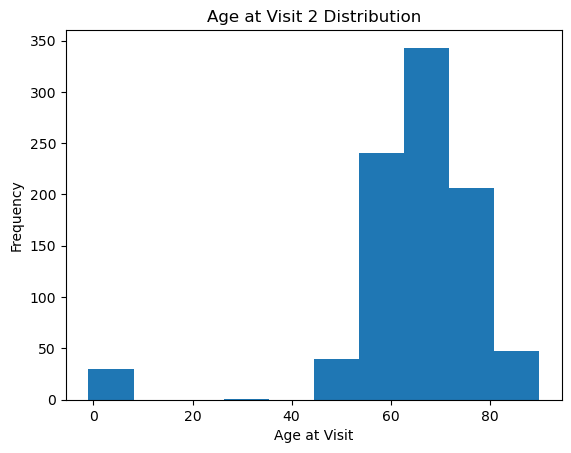

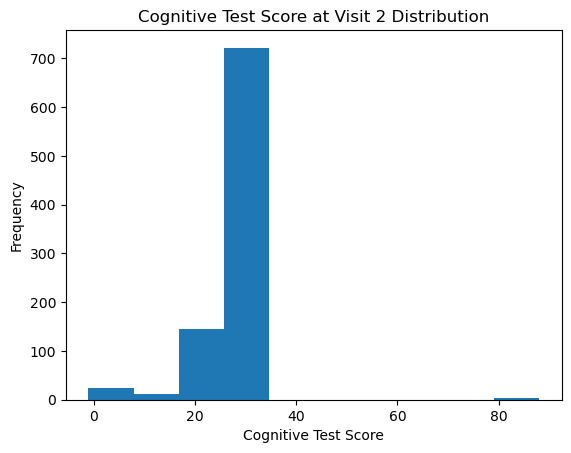

For visit 2 of gender Male: age at visit stats =
mean    67.802260
std      8.428697
min     46.000000
max     90.000000
Name: age_at_visit, dtype: float64
For visit 2 of gender Male: AD value counts =
ad
 0    247
 1     89
-1     31
Name: count, dtype: int64
For visit 2 of gender Male: MCI_SCI value counts =
mci_sci
 0    216
-1     93
 1     58
Name: count, dtype: int64
For visit 2 of gender Male: cognitive test score stats =
mean    27.210959
std      5.790945
min      0.000000
max     88.000000
Name: cognitive_test_score, dtype: float64
For visit 2 of gender Male: cognitive test score (0-30) stats =
mean    27.043956
std      4.839375
min      0.000000
max     30.000000
Name: cognitive_test_score, dtype: float64


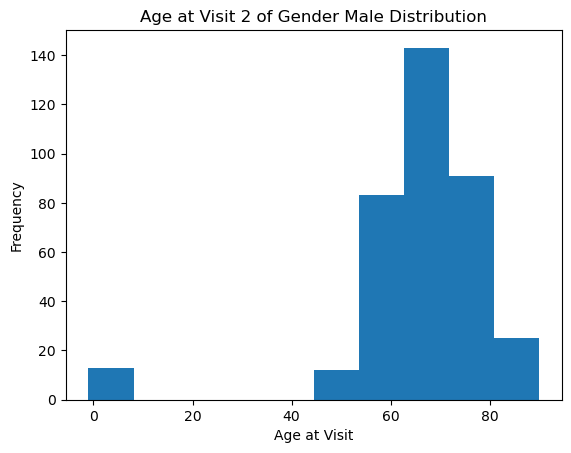

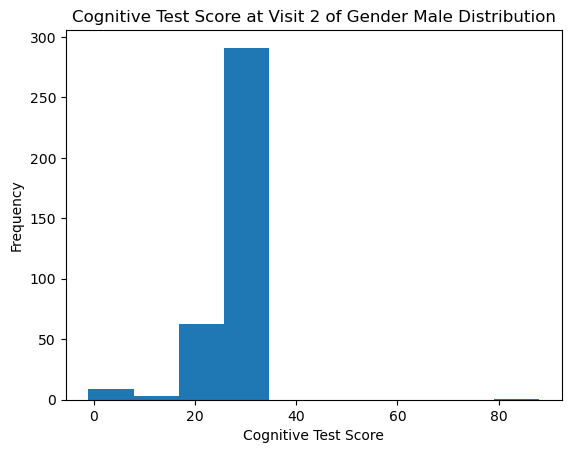

For visit 2 of gender Female: age at visit stats =
mean    65.871893
std      8.289588
min     33.000000
max     90.000000
Name: age_at_visit, dtype: float64
For visit 2 of gender Female: AD value counts =
ad
 0    387
 1    101
-1     52
Name: count, dtype: int64
For visit 2 of gender Female: MCI_SCI value counts =
mci_sci
 0    337
-1    112
 1     91
Name: count, dtype: int64
For visit 2 of gender Female: cognitive test score stats =
mean    27.223048
std      6.165507
min      0.000000
max     88.000000
Name: cognitive_test_score, dtype: float64
For visit 2 of gender Female: cognitive test score (0-30) stats =
mean    26.996269
std      4.929028
min      0.000000
max     30.000000
Name: cognitive_test_score, dtype: float64


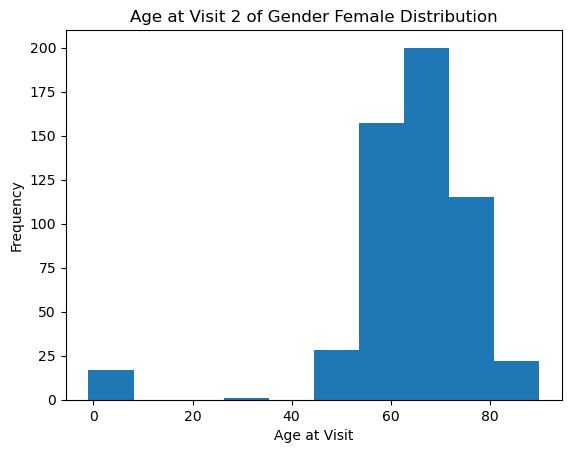

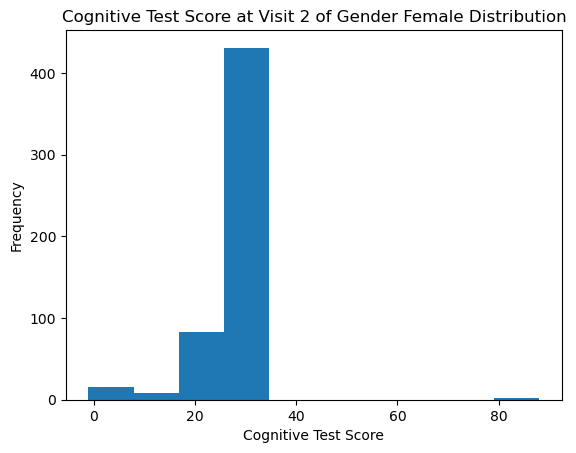

For visit 3: age at visit stats =
mean    69.632839
std      8.398859
min     38.000000
max     90.000000
Name: age_at_visit, dtype: float64
For visit 3: AD value counts =
ad
 0    594
 1    189
-1    124
Name: count, dtype: int64
For visit 3: MCI_SCI value counts =
mci_sci
 0    534
-1    206
 1    167
Name: count, dtype: int64
For visit 3: cognitive test score stats =
mean    27.033408
std      6.145486
min      0.000000
max     88.000000
Name: cognitive_test_score, dtype: float64
For visit 3: cognitive test score (0-30) stats =
mean    26.82905
std      5.03776
min      0.00000
max     30.00000
Name: cognitive_test_score, dtype: float64


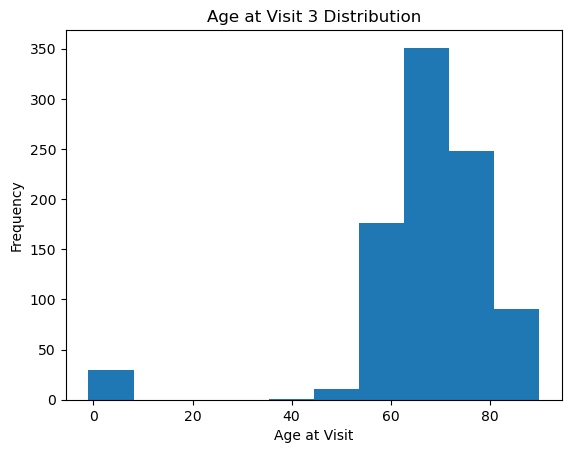

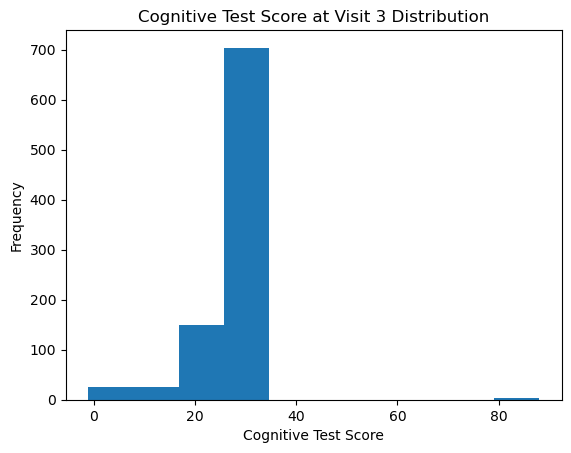

For visit 3 of gender Male: age at visit stats =
mean    70.754237
std      8.552060
min     47.000000
max     90.000000
Name: age_at_visit, dtype: float64
For visit 3 of gender Male: AD value counts =
ad
 0    235
 1     89
-1     43
Name: count, dtype: int64
For visit 3 of gender Male: MCI_SCI value counts =
mci_sci
 0    204
-1     93
 1     70
Name: count, dtype: int64
For visit 3 of gender Male: cognitive test score stats =
mean    26.865753
std      5.953672
min      0.000000
max     88.000000
Name: cognitive_test_score, dtype: float64
For visit 3 of gender Male: cognitive test score (0-30) stats =
mean    26.697802
std      5.021924
min      0.000000
max     30.000000
Name: cognitive_test_score, dtype: float64


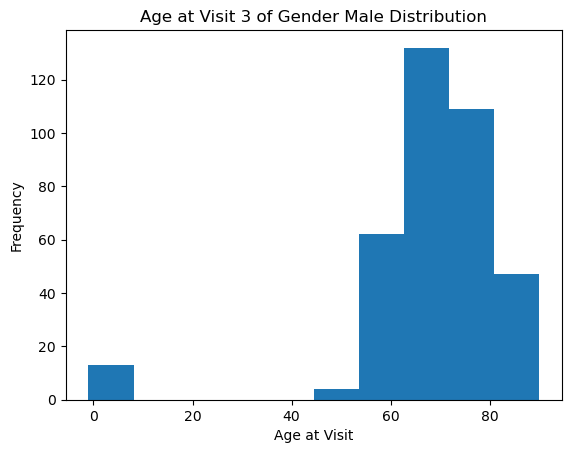

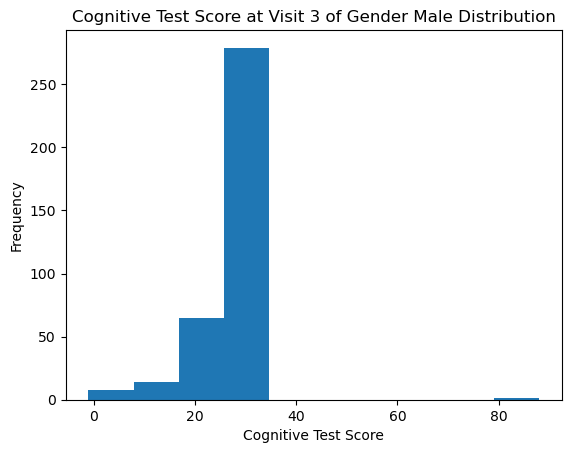

For visit 3 of gender Female: age at visit stats =
mean    68.873805
std      8.215217
min     38.000000
max     90.000000
Name: age_at_visit, dtype: float64
For visit 3 of gender Female: AD value counts =
ad
 0    359
 1    100
-1     81
Name: count, dtype: int64
For visit 3 of gender Female: MCI_SCI value counts =
mci_sci
 0    330
-1    113
 1     97
Name: count, dtype: int64
For visit 3 of gender Female: cognitive test score stats =
mean    27.148218
std      6.276416
min      0.000000
max     88.000000
Name: cognitive_test_score, dtype: float64
For visit 3 of gender Female: cognitive test score (0-30) stats =
mean    26.919021
std      5.051344
min      0.000000
max     30.000000
Name: cognitive_test_score, dtype: float64


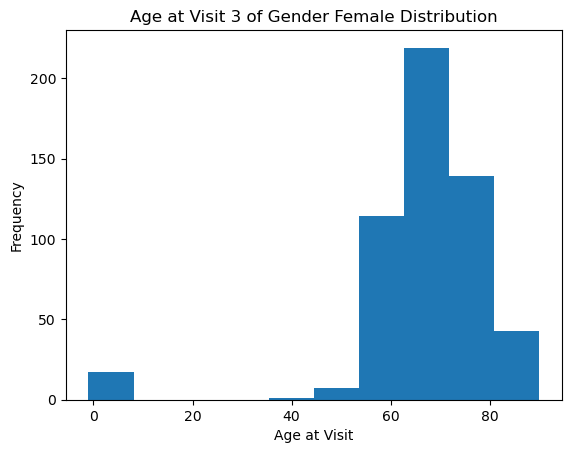

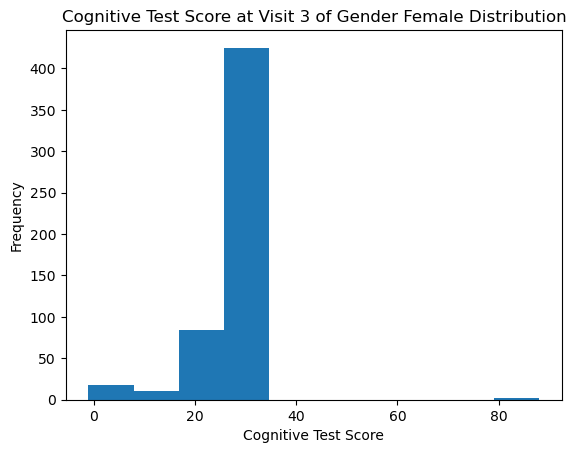

In [152]:
def longitudinal_stats(df, visit_thres=3):
    multi_visit_df = filter_multi_visit_patients(df, min_visits=visit_thres)
    sex_encoding = {1: "Male", 2: "Female"}
    for visit in range(1, visit_thres + 1):
        visit_df = multi_visit_df[multi_visit_df["visit"] == visit]
        visit_stats(visit_df, visit)
        for sex_code, sex_name in sex_encoding.items():
            visit_sex_df = visit_df[visit_df["sex"] == sex_code]
            if visit_sex_df.empty:
                print(f"No data for visit {visit} and gender {sex_name}.")
            else:
                visit_stats(visit_sex_df, visit, sex=sex_name)
longitudinal_stats(AD_plasma_longitudinal, visit_thres=3)


In [ ]:
def longitudinal_stats(df_merged, converter=False, detail=False):
    df_merged = df_merged[df_merged["age_at_visit"] != -1]

    # Group by person_id and generate list of sub-dataframes
    subdfs = [subdf for _, subdf in df_merged.groupby("person_id")]
    subdfs_multi_visit = [subdf for subdf in subdfs if subdf["visit"].max() > 1 and len(subdf) > 1]
    cohorts = []
    for df in subdfs_multi_visit:
        cohorts.append(df["contributor_code"].iloc[0])
        if df["contributor_code"].nunique() > 1:
            raise ValueError("Cohort inconsistency within the same person_id.")

    if converter:
        converted_subdfs_multi_visit = [df for df in subdfs_multi_visit if df["ad"].nunique() > 1 or df["ftd"].nunique() > 1 or df["pd"].nunique() > 1 or df["als"].nunique() > 1 or df["mci_sci"].nunique() > 1 or df["recruited_control"].nunique() > 1]

    print(f"\nTotal unique persons: {len(subdfs)}")
    print(f"Total persons with multiple visits: {len(subdfs_multi_visit)}")
    print(f"Total number of multiple visits: {sum(len(subdf) for subdf in subdfs_multi_visit)}")
    print("Different cohorts in multi-visit persons:", set(cohorts))
    if converter:
        print(f"Total persons with diagnosis changes over visits: {len(converted_subdfs_multi_visit)}")
    if detail:
        for i, subdf in enumerate(subdfs_multi_visit):
            print(f"\nPerson ID: {subdf['person_id'].iloc[0]} - Number of Visits: {len(subdf)}")
            print(subdf[['sample_id', 'visit', 'age_at_visit', 'ad', 'ftd', 'pd', 'als']])
    return subdfs_multi_visit


In [ ]:
def multi_visit_by_disease(df_multi_visit, disease_col):
    disease_groups = []
    cohorts = []
    total_disease_count = len(disease_col)
    for df in df_multi_visit:
        count = 0
        for disease in disease_col:
            if (df[disease] == 1).any():
                count += 1
        if count == total_disease_count:
            disease_groups.append(df)
            cohorts.append(df["contributor_code"].iloc[0])
            if df["contributor_code"].nunique() > 1:
                raise ValueError("Cohort inconsistency within the same person_id.")
    print(f"Total persons with multiple visits and {disease_col}=1: {len(disease_groups)}")
    print("Different cohorts in this group:", set(cohorts))
    return disease_groups

In [ ]:
def multi_visit_no_disease(df_multi_visit):
    disease_groups = []
    cohorts = []
    disease_col = ["ad", "ftd", "pd", "als", "mci_sci", "recruited_control"]
    total_disease_count = len(disease_col)
    for df in df_multi_visit:
        count = 0
        for disease in disease_col:
            if (df[disease] == 1).any():
                count += 1
        if count == 0:
            disease_groups.append(df)
            cohorts.append(df["contributor_code"].iloc[0])
            if df["contributor_code"].nunique() > 1:
                raise ValueError("Cohort inconsistency within the same person_id.")
    print(f"Total persons with multiple visits and no diagnoised disease: {len(disease_groups)}")
    print("Different cohorts in this group:", set(cohorts))
    return disease_groups

In [ ]:
def sample_summary(df, cols = None):
    if cols is None:
        cols = ["person_id", "sample_id", "sex", "sample_type", "visit", "age_at_visit", "ad", "ftd", "pd", "als", "mci_sci", "recruited_control", "cdr", "cognitive_test_date", "cognitive_test_score", "computed_cognitive_test_score", "cognitive_test_battery", "computed_clinical_diagnosis", "computed_cognitive_impairment", "is_neuropath", "is_biomarker"]
    subdf = df[cols]
    return subdf